# **Práctica 2.3: Visualización**

<hr>

## **1. Objetivo**
En esta práctica utilizaremos el conjunto generado en la práctica anterior y visualizaremos diversos datos a fin de extraer conocimiento. 

Para ello necesitaremos instalar nuevas librerías en nuestro environment conda.


##### **Matplotlib**

Librería que permite realizar una gran variedad de gráficos, entre los que se encuentran:

* Histogramas.
* Gráficos de dispersión.
* Gráficos de barras.
* Mapas de calor.
* Etc.

Posee múltiples opciones de personalización.  
Una vez generados, los graficos pueden ser exportados en numerosos formatos (jpg, png, pdf...)

Ejemplo: https://matplotlib.org/gallery/lines_bars_and_markers/scatter_demo2.html#sphx-glr-gallery-lines-bars-and-markers-scatter-demo2-py

*Para instalarla:*


In [194]:
! pip install matplotlib

##### **Seaborn**

Basada en Matplotlib, esta librería actúa como interfaz de alto nivel sobre la anterior.  
De esta forma simplifica en gran medida las operaciones más comunes.  
Tambien añade gráficos nuevos.

Ejemplo: https://seaborn.pydata.org/examples/scatter_bubbles.html

*Para instalarla:*

In [195]:
! pip install seaborn

##### **Bokeh**

A diferencia de las anteriores, Bokeh permite generar gráficos interactivos.  
Gracias a esto, podremos modificar el gráfico una vez realizado.

Ejemplo: https://demo.bokeh.org/crossfilter

*Para instalarla:*

In [196]:
! pip install bokeh

<hr>

## **2. Visualización de datos**

Lo primero que tendremos que hacer será cargar los datos de la práctica anterior.

In [197]:
import pandas as pd
data = pd.read_pickle("https://raw.githubusercontent.com/AIC-Uniovi/Sistemas-Inteligentes/refs/heads/main/datasets/f1_23_monaco.pkl")

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Verifica que los tipos de datos son los correctos.
</div>

In [198]:
# Tu código aquí
print(data.dtypes)


Time              timedelta64[ns]
Driver                     object
DriverNumber                int64
LapTime           timedelta64[ns]
LapNumber                   int64
Stint                       int64
Sector1Time       timedelta64[ns]
Sector2Time       timedelta64[ns]
Sector3Time       timedelta64[ns]
SpeedI1                   float64
SpeedI2                   float64
SpeedFL                   float64
SpeedST                   float64
IsPersonalBest               bool
Compound                   object
TyreLife                    int64
FreshTyre                    bool
Team                       object
LapStartTime      timedelta64[ns]
LapStartDate       datetime64[ns]
Position                    int64
dtype: object


### **2.1. Visualización estática**
Comenzaremos con la visualización estática, la cual no permite manipular el gráfico una vez generado.

Primero cargaremos las librerías y fijaremos unas variables que se utilizarán a lo largo de la práctica.


In [199]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid") # Establece el estilo de los gráficos
import bokeh as bk

# Tamaño de los gráficos
fig_size=(12,6) 
# Diccionario de colores para cada equipo, piloto y neumático
team_colors = {'Red Bull Racing': '#1E41FF', 'Alpine': '#2293D1', 'Aston Martin': '#006F62', 'Ferrari': '#DC0000', 'Williams': '#005AFF', 'Haas F1 Team': '#787878', 'AlphaTauri': '#2B4562', 'Alfa Romeo': '#900000', 'McLaren': '#FF8700', 'Mercedes': '#6CD3BF'}
driver_colors = {'VER': '#1E41FF', 'GAS': '#2293D1', 'PER': '#1E41FF', 'ALO': '#006F62', 'LEC': '#DC0000', 'STR': '#006F62', 'SAR': '#005AFF', 'MAG': '#787878', 'DEV': '#2B4562', 'TSU': '#2B4562', 'ALB': '#005AFF', 'ZHO': '#900000', 'HUL': '#787878', 'OCO': '#2293D1', 'NOR': '#FF8700', 'HAM': '#6CD3BF', 'SAI': '#DC0000', 'RUS': '#6CD3BF', 'BOT': '#900000', 'PIA': '#FF8700'}
tire_colors = { 'SOFT': '#FF0000', 'HARD': '#cccccc', 'MEDIUM': '#FFD700', 'INTERMEDIATE': '#00A550', 'WET': '#005AFF' }

#### **Distribuciones**

Las distribuciones se obtienen con el objetivo de mostrar los posibles valores que puede poseer una variable concreta. Además podemos ver la frecuencia de los mismos.

_Para una variable:_
* Histograma : `sns.histplot` o `sns.countplot`
* KDE (Kernel Density Estimate): `sns.kdeplot`

El KDE es una versión suavizada de un histograma donde el eje y muestra qué tan probable es encontrar un valor en cada punto, en lugar de solo contar cuántos datos hay en cada intervalo.

_Para varias variables:_
* KDE2D: `sns.jointplot`

**Histograma de la columna "SpeedI1".**

Text(0.5, 1.0, "Histograma de la variable 'SpeedI1'")

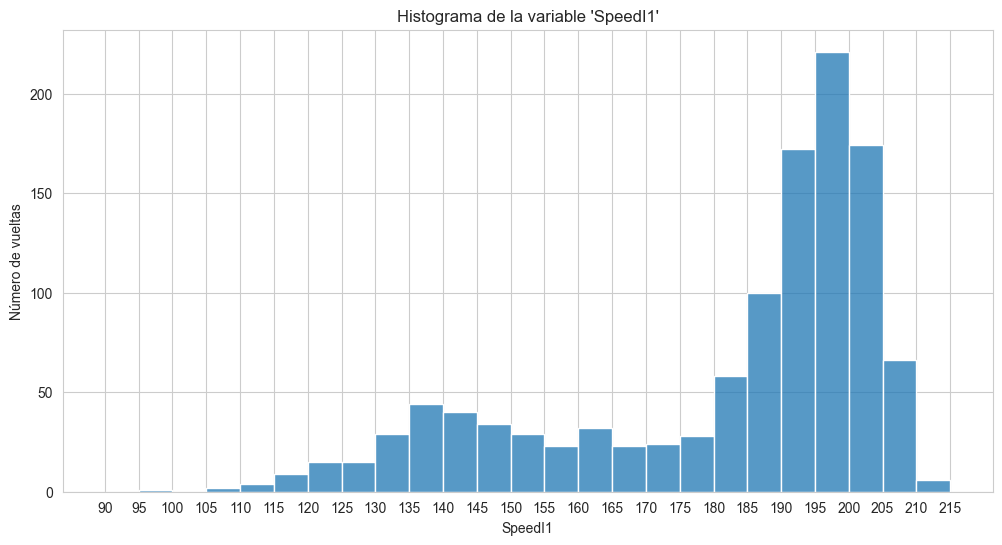

In [200]:
plt.figure(figsize=fig_size); # Tamaño del plot
histo = sns.histplot(data=data['SpeedI1'], kde=False, bins=range(90,220,5));
histo.set_xticks(range(90,220,5)); # Etiquetas del eje X
histo.set_xlabel("SpeedI1")
histo.set_ylabel("Número de vueltas")
histo.set_title("Histograma de la variable 'SpeedI1'")

**Otra notación para lo anterior**

Text(0.5, 1.0, "Histograma de la variable 'SpeedI1'")

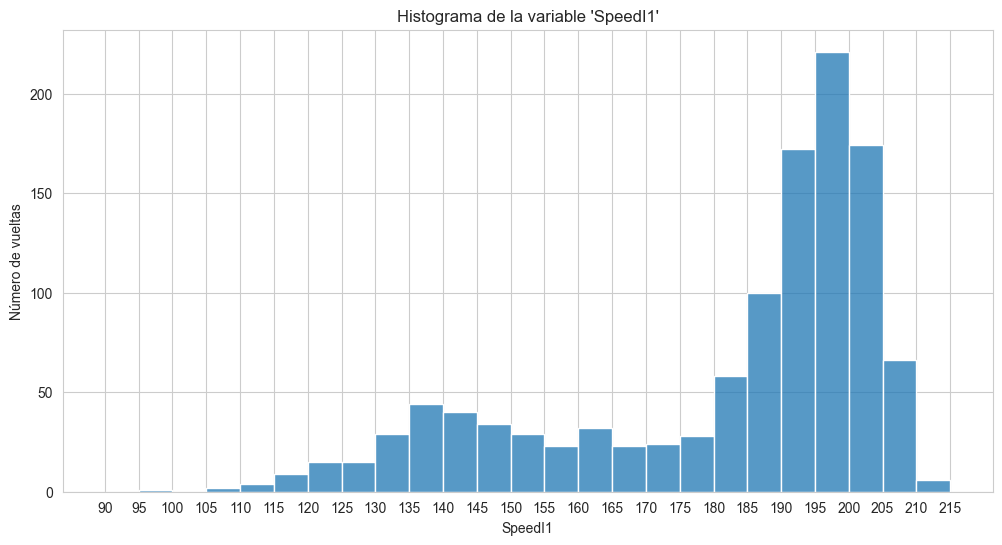

In [201]:
# Otra notación
plt.figure(figsize=fig_size);
histo = sns.histplot(data=data, x="SpeedI1", kde=False, bins=range(90,220,5)); 
histo.set_xticks(range(90,220,5)); 
histo.set_xlabel("SpeedI1") 
histo.set_ylabel("Número de vueltas") 
histo.set_title("Histograma de la variable 'SpeedI1'")

**Histograma del número de vueltas por equipo**

Equipo, como sabrás, es una variable categórica, por eso utilizamos countplot.

Text(0.5, 1.0, "Histograma de la variable 'Team'")

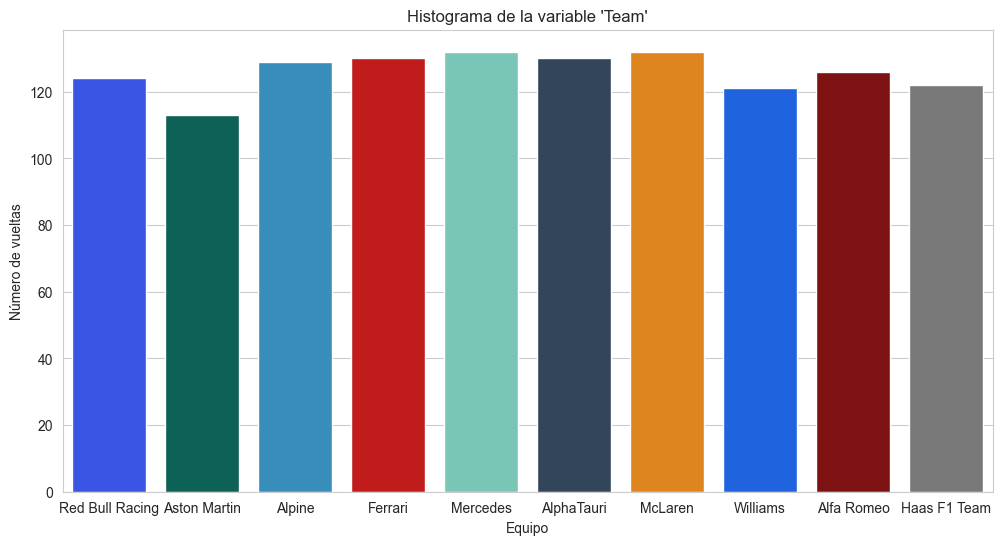

In [202]:
plt.figure(figsize=fig_size); # Tamaño del plot
histo = sns.countplot(x=data['Team'], hue=data["Team"], palette=team_colors);
histo.set_xlabel("Equipo")
histo.set_ylabel("Número de vueltas")
histo.set_title("Histograma de la variable 'Team'")

**KDE de la velocidad en la línea de meta de los pilotos: ALO, VER, LEC y NOR**

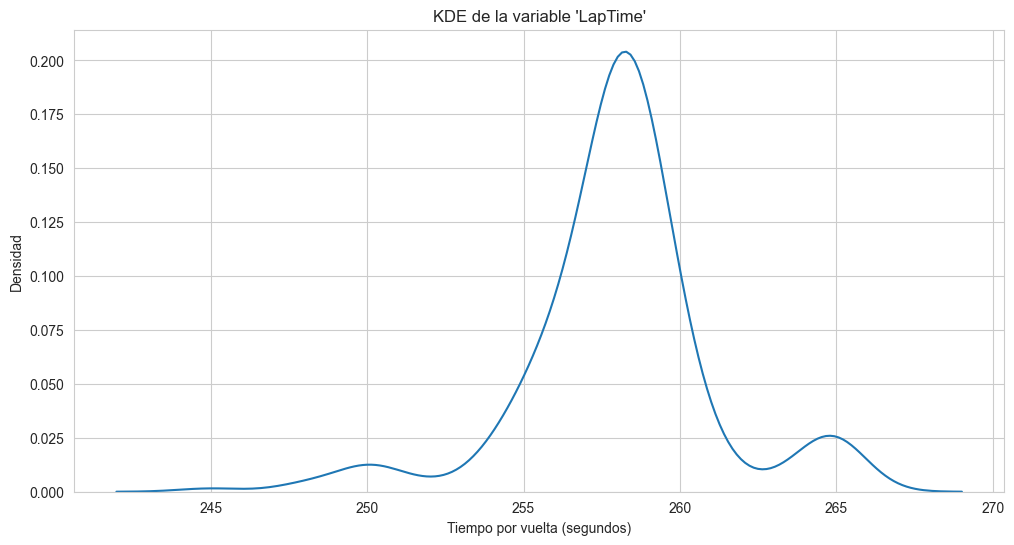

In [203]:
filtered_drivers = data.loc[data["Driver"].isin(["ALO", "VER", "LEC", "NOR"])]

plt.figure(figsize=fig_size)
histo = sns.kdeplot(data=filtered_drivers, x=filtered_drivers["SpeedFL"])
histo.set_xlabel("Tiempo por vuelta (segundos)")
histo.set_ylabel("Densidad")
histo.set_title("KDE de la variable 'LapTime'")
plt.show()

**KDE (separado por piloto) de la velocidad en la línea de meta de los pilotos: ALO, VER, LEC y NOR**

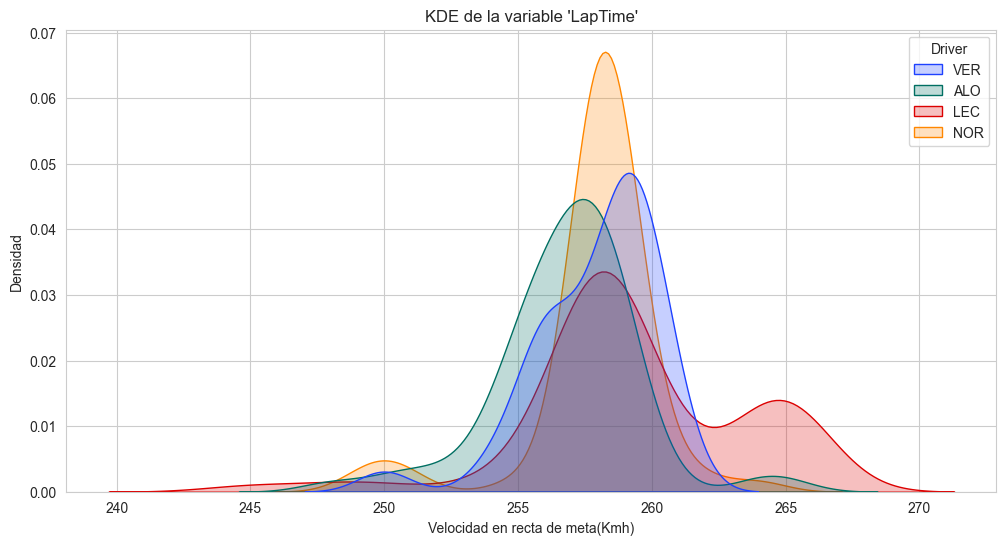

In [204]:
plt.figure(figsize=fig_size)
histo = sns.kdeplot(data=filtered_drivers, x=filtered_drivers["SpeedFL"], hue="Driver", palette=driver_colors, fill=True)
histo.set_xlabel("Velocidad en recta de meta(Kmh)")
histo.set_ylabel("Densidad")
histo.set_title("KDE de la variable 'LapTime'")
plt.show()

**KDE 2D (separado por piloto) del tiempo en el primer sector frente al del tercero de ALO, VER, LEC y NOR para las primeras 30 vueltas**

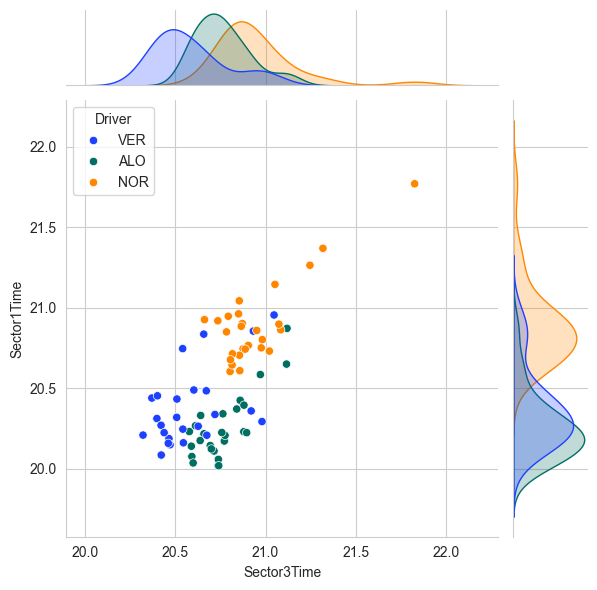

In [205]:
filtered_drivers = data.loc[(data["LapNumber"]<=30)&(data["Driver"].isin(["VER", "ALO", "NOR"]))]
histo = sns.jointplot(data=filtered_drivers, x=filtered_drivers["Sector3Time"].dt.total_seconds(), y=filtered_drivers["Sector1Time"].dt.total_seconds(), hue="Driver", palette=driver_colors)
plt.show()

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Crea un gráfico con el número de vueltas realizadas con cada tipo de neumático. Utiliza la variable "tire_colors" ya creada.
</div>

Text(0.5, 1.0, "Histograma de la variable 'Compound'")

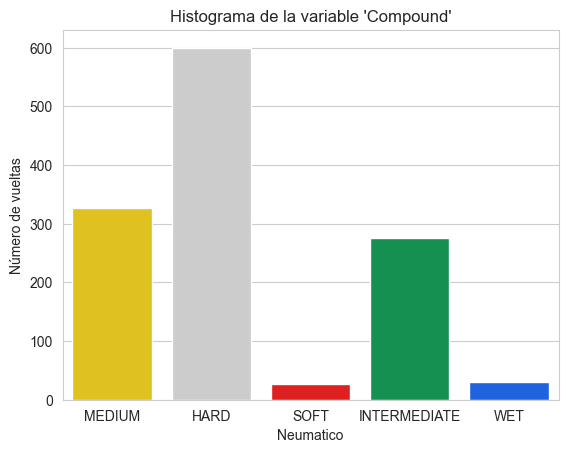

In [206]:
# Tu código aquí
histo = sns.countplot(x=data['Compound'], hue=data["Compound"], palette=tire_colors);
histo.set_xlabel("Neumatico")
histo.set_ylabel("Número de vueltas")
histo.set_title("Histograma de la variable 'Compound'")

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Crea un gráfico con las posiciones por las que ha pasado Kevin Magnussen (MAG). Ha de reflejar cuantas vueltas ha estado en cada una de las 20 posiciones. Han de aparecer todas las posibles posiciones en el eje x.
</div>

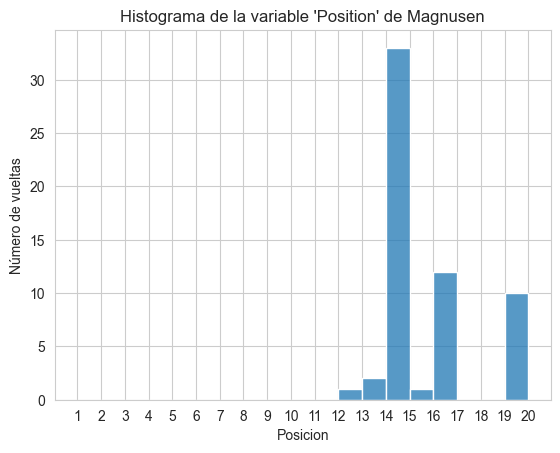

In [231]:

data_amg = data.loc[data["Driver"]== "MAG"]
histo = sns.histplot(data=data_amg, x="Position", kde=False, bins=range(1,21,1)); 
histo.set_xticks(range(1,21,1)); 
histo.set_xlabel("Posicion") 
histo.set_ylabel("Número de vueltas") 
histo.set_title("Histograma de la variable 'Position' de Magnusen")
plt.show()

#### **Relaciones**

Existen múltiples tipos de gráficos para representar la relación entre variables (2 típicamente).

_Para 2 variables:_
* Barras : `sns.barplot`
* Linea : `sns.lineplot`
* Dispersión: `sns.scatterplot`
* Linea de regresión: `sns.regplot`

_Para más variables:_
* Color y tamaño para representar más información.
* Por pares : `sns.lineplot`
* Visualización 3D: `mpl_toolkits.mplot3d`
* Reducir a 2 variables:
  * PCA (Principal Component Analysis): `sklearn.decomposition.PCA`
  * TSNE (T-distributed Stochastic Neighbor Embedding) : `sklearn.manifold.TSNE`

**Gráfico de barras: Relación entre tiempo por vuelta y posición.**

Text(0.5, 1.0, 'Relación entre Tiempo por vuelta y Posición')

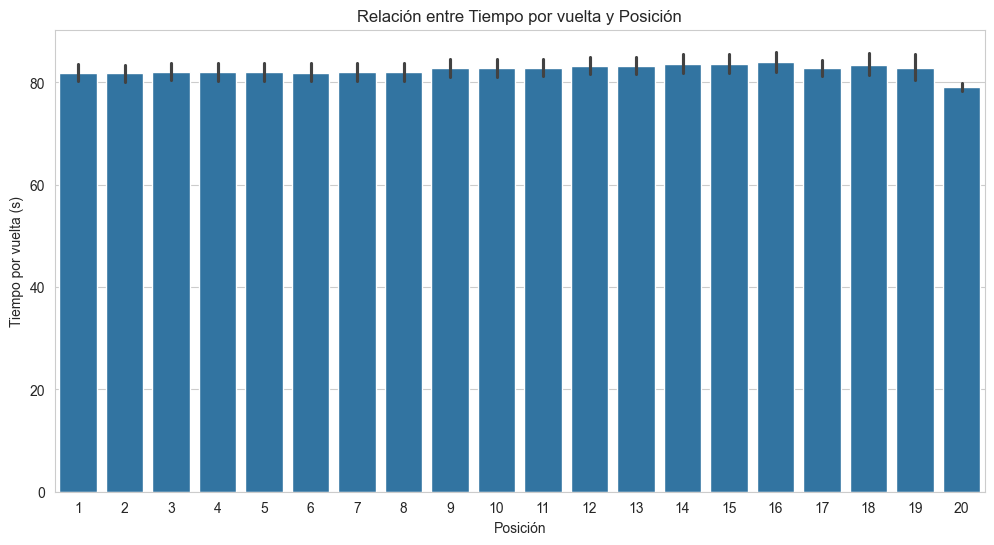

In [208]:
plt.figure(figsize=fig_size); # Tamaño del plot
the_plot = sns.barplot(data=data, x='Position', y=data["LapTime"].dt.total_seconds())
the_plot.set_xlabel("Posición")
the_plot.set_ylabel("Tiempo por vuelta (s)")
the_plot.set_title("Relación entre Tiempo por vuelta y Posición")

**Gráfico de barras: Tiempo medio por vuelta para cada neumático.**

Text(0.5, 1.0, 'Relación entre Tiempo por vuelta y Posición')

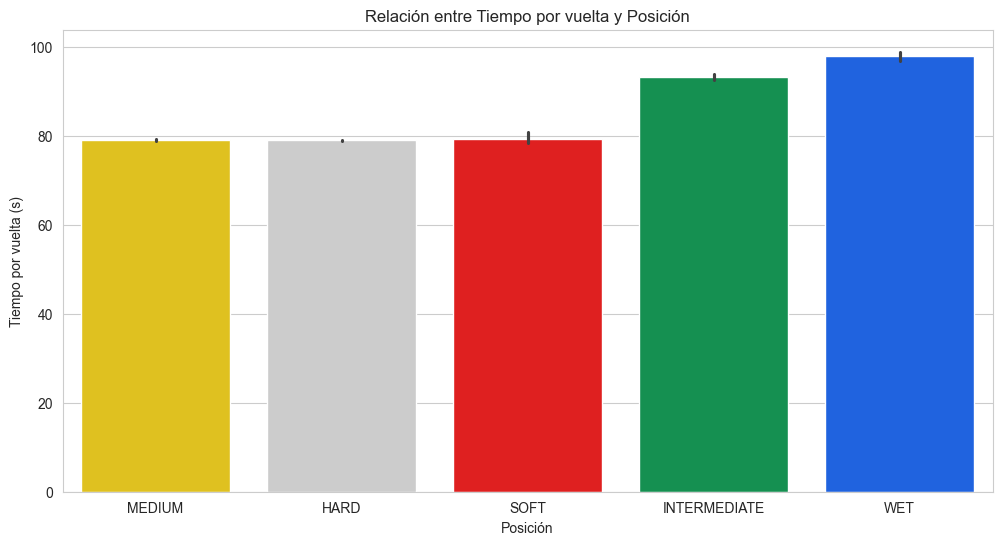

In [209]:
plt.figure(figsize=fig_size); # Tamaño del plot
the_plot = sns.barplot(data=data, x='Compound', y=data["LapTime"].dt.total_seconds(), hue="Compound", palette=tire_colors)
the_plot.set_xlabel("Posición")
the_plot.set_ylabel("Tiempo por vuelta (s)")
the_plot.set_title("Relación entre Tiempo por vuelta y Posición")

**Gráfico de linea: Relación entre tiempo por vuelta y número de vuelta.**

Text(0.5, 1.0, 'Relación entre Tiempo por vuelta y Vuelta')

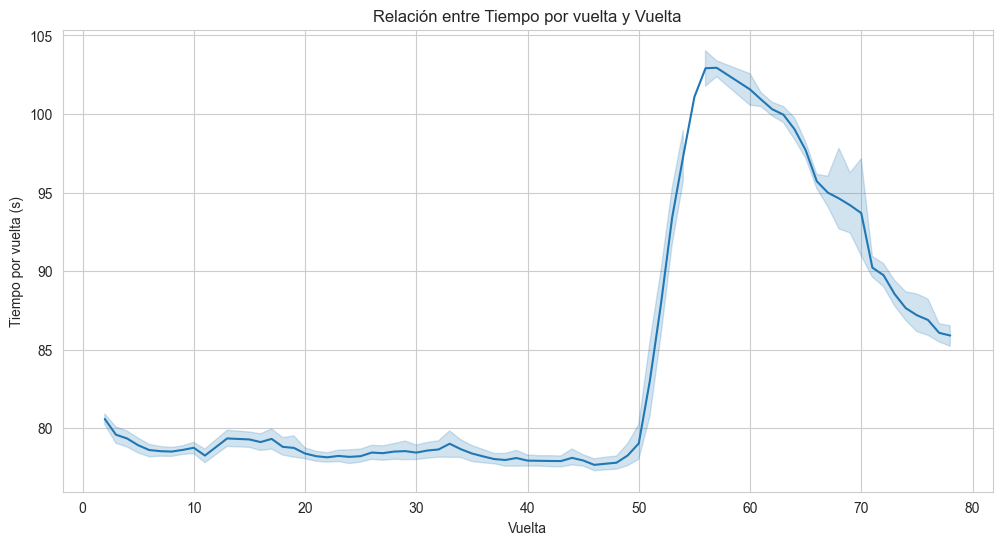

In [210]:
plt.figure(figsize=fig_size); # Tamaño del plot
the_plot = sns.lineplot(data=data, x='LapNumber', y=data["LapTime"].dt.total_seconds())
the_plot.set_xlabel("Vuelta")
the_plot.set_ylabel("Tiempo por vuelta (s)")
the_plot.set_title("Relación entre Tiempo por vuelta y Vuelta")

**Gráfico de dispersión: Relación entre los tiempos del segundo sector y la velocidad en el segundo punto de detección en función del neumático.**

Text(0.5, 1.0, 'Relación entre el tiempo en el segundo sector y la velocidad segundo punto')

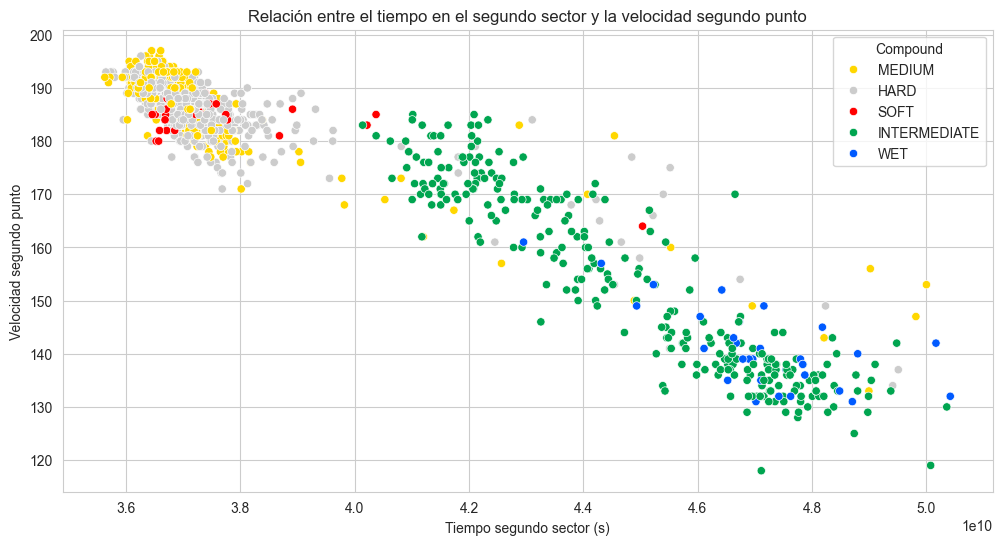

In [211]:
plt.figure(figsize=fig_size); # Tamaño del plot
the_plot = sns.scatterplot(data=data, x='Sector2Time', y='SpeedI2', hue="Compound", palette=tire_colors);
the_plot.set_ylabel("Velocidad segundo punto")
the_plot.set_xlabel("Tiempo segundo sector (s)")
the_plot.set_title("Relación entre el tiempo en el segundo sector y la velocidad segundo punto")

**Añadiendo línea de tendencia anterior**

El gráfico adecuado es el "regplot". Este no soporta el parámetro "hue".

Text(0.5, 1.0, 'Relación entre el tiempo en el segundo sector y la velocidad segundo punto')

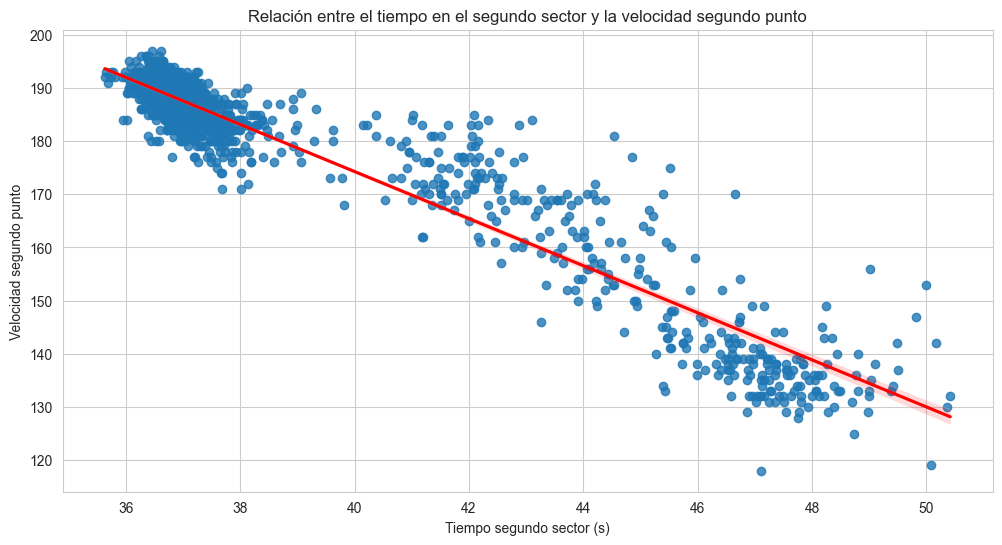

In [212]:
plt.figure(figsize=fig_size); # Tamaño del plot
the_plot = sns.regplot(data=data, x=data['Sector2Time'].dt.total_seconds(), y='SpeedI2', line_kws={'color':'red'});
the_plot.set_ylabel("Velocidad segundo punto")
the_plot.set_xlabel("Tiempo segundo sector (s)")
the_plot.set_title("Relación entre el tiempo en el segundo sector y la velocidad segundo punto")

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Obtén el gráfico anterior para las vueltas después de la 55.
</div>

Text(0.5, 1.0, 'Relación entre el tiempo en el segundo sector y la velocidad segundo punto despues de la vuelta 55')

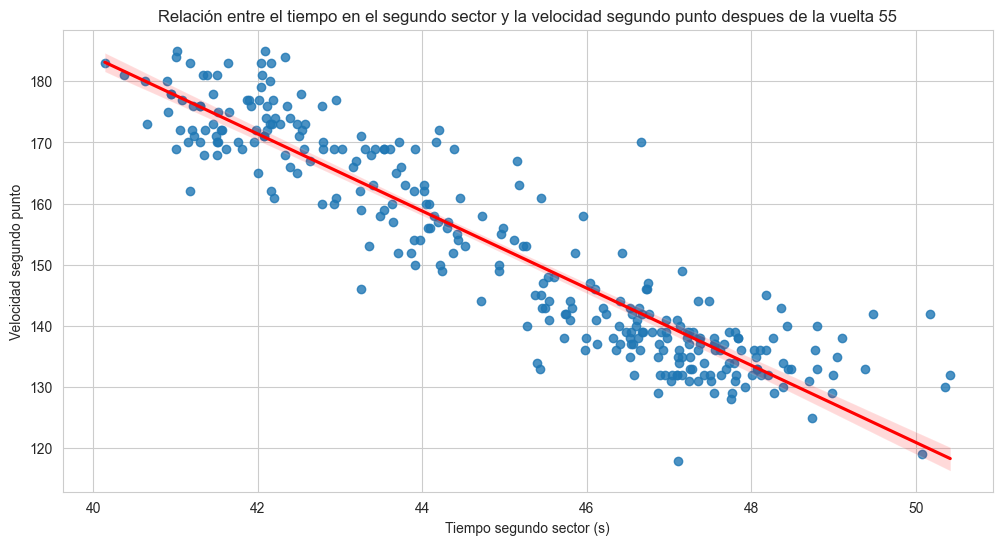

In [234]:
# Tu código aquí
data_55 = data.loc[data["LapNumber"]>55]
plt.figure(figsize=fig_size); # Tamaño del plot
the_plot = sns.regplot(data=data_55, x=data_55['Sector2Time'].dt.total_seconds(), y='SpeedI2', line_kws={'color':'red'});
the_plot.set_ylabel("Velocidad segundo punto")
the_plot.set_xlabel("Tiempo segundo sector (s)")
the_plot.set_title("Relación entre el tiempo en el segundo sector y la velocidad segundo punto despues de la vuelta 55")

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Crea un gráfico con el tiempo por vuelta medio (máximo y mínimo) para cada piloto.
</div>

In [ ]:
# Tu código aquí
data[("Driver","LapTime")].sort("Laptime")

KeyError: ('Driver', 'LapTime')

#### **Relaciones: *Múltiples variables***

**Color y forma para representar más información.**

Text(0.5, 1.0, 'Relación entre tiempos de sectores 3 y 2')

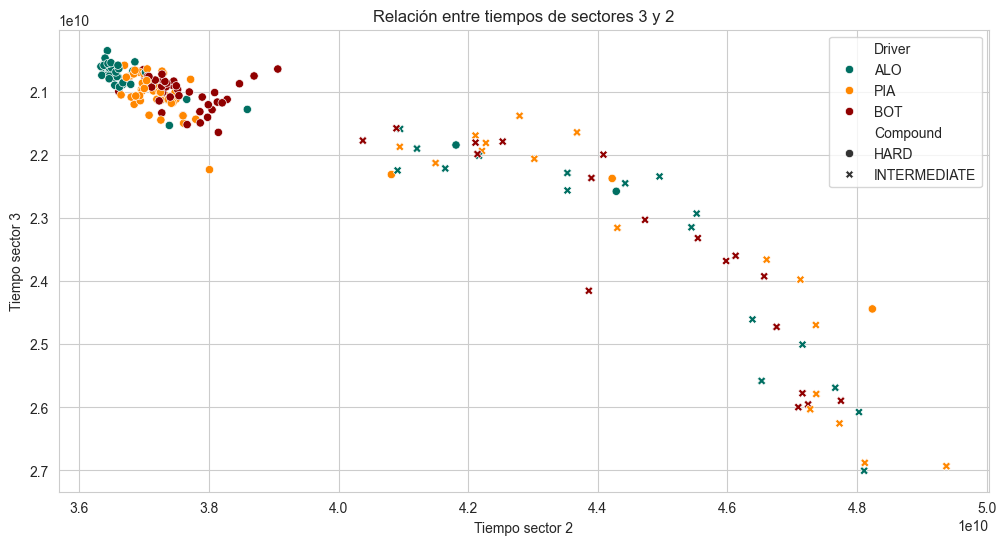

In [215]:
plt.figure(figsize=fig_size); # Tamaño del plot
plt_data = data.loc[data.Driver.isin(["ALO", "BOT", "PIA"])]
the_plot = sns.scatterplot(data=plt_data, x='Sector2Time', y='Sector3Time', hue='Driver', style="Compound", palette=driver_colors)
the_plot.set_xlabel("Tiempo sector 2")
the_plot.set_ylabel("Tiempo sector 3")
the_plot.set_title("Relación entre tiempos de sectores 3 y 2")

**Por pares: Relación entre "SpeedI1","SpeedI2","SpeedFL".**

<Figure size 1200x600 with 0 Axes>

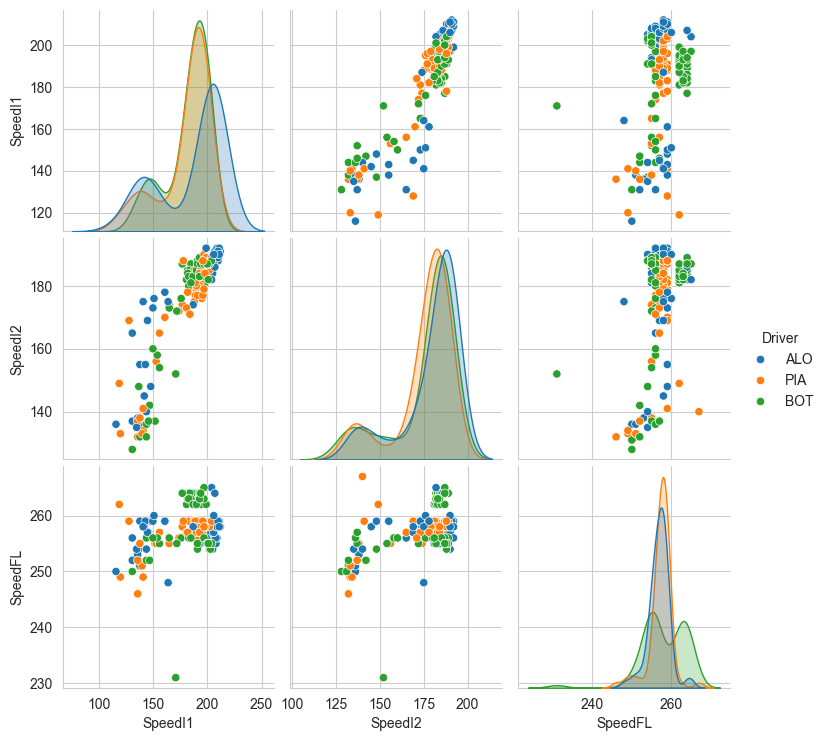

In [216]:
plt.figure(figsize=fig_size); # Tamaño del plot
plt_data = data.loc[data.Driver.isin(["ALO", "BOT", "PIA"])]
the_plot = sns.pairplot(data=plt_data, vars=["SpeedI1","SpeedI2","SpeedFL"], hue="Driver")

**Dispersión en 3D. Es necesario utilizar la librería matplotlib.**

Text(0.5, 0.92, 'Gráfico de dispersión en 3D')

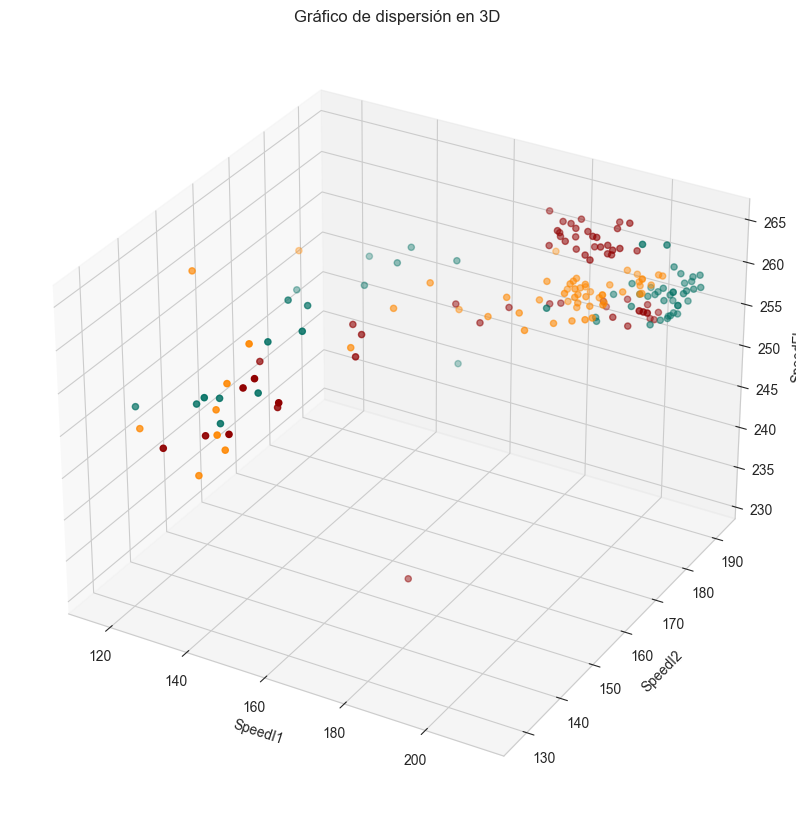

In [217]:
from mpl_toolkits import mplot3d # Importar la parte 3D de la librería matplotlib

plt_data = data.loc[data.Driver.isin(["ALO", "BOT", "PIA"])]
plt.figure(figsize=(10,12)); # Tamaño del plot
ax = plt.axes(projection='3d') # Indicar el tipo de gráfico
ax.scatter3D(plt_data["SpeedI1"], plt_data["SpeedI2"], plt_data["SpeedFL"], c=plt_data["Driver"].apply(lambda x: driver_colors[x]))
plt.xlabel("SpeedI1")
plt.ylabel("SpeedI2")
ax.set_zlabel("SpeedFL")

plt.title("Gráfico de dispersión en 3D")

#### **Relaciones: *Mapas de calor***
Este tipo de gráfico es muy típico cuando disponemos de una tabla con datos (``pivot_table``, por ejemplo) y queremos facilitar la identificación inmediata de patrones, tendencias y valores atípicos.

Text(0.5, 1.0, 'Mapa de calor')

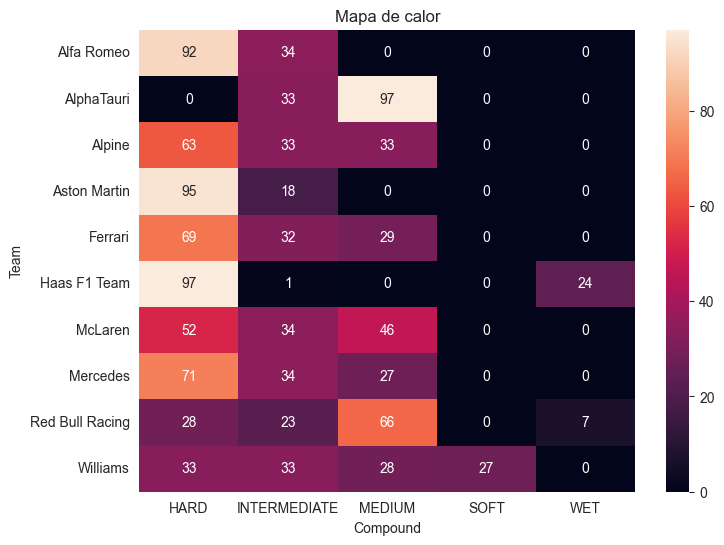

In [218]:
plt_data = data.pivot_table(index=["Team"], columns=["Compound"], values="LapNumber", aggfunc="count", fill_value=0)

plt.figure(figsize=(8,6)); # Tamaño del plot
sns.heatmap(plt_data, annot=True)
plt.title("Mapa de calor")

#### **Relaciones: *Múltiples variables con reducción dimensionalidad***

Cuando trabajamos con datos que tienen muchas dimensiones (más de 2) es difícil visualizarlos directamente. Para entender su estructura y encontrar patrones, necesitamos reducir la cantidad de dimensiones sin perder demasiada información. El PCA y el t-SNE son dos métodos que nos ayudan a visualizar datos con muchas dimensiones reduciéndolos a 2D o 3D.

Para utilizar estos métodos necesitamos instalar previamente la librería scikit-learn:


In [219]:
! pip install scikit-learn

**PCA: Visualizar las vueltas de 3 pilotos en función de 6 variables: el tiempo en cada uno de los 3 sectores y la velocidades máximas.**

Text(0.5, 1.0, 'Reducción de dimensiones mediante PCA')

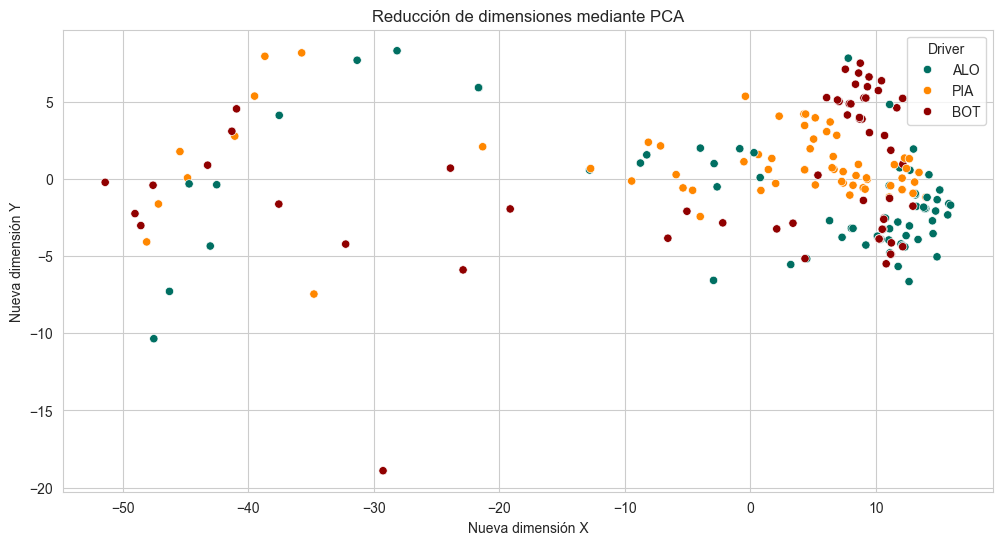

In [220]:
from sklearn.decomposition import PCA # Importar PCA

filtered_data = data.loc[data.Driver.isin(["ALO", "BOT", "PIA"])].copy() # Mejor hacer una copia si se va a modificar posteriormente
# Vamos a pasar de timedelta a float los tiempos de los sectores
filtered_data[["Sector1Time", "Sector2Time", "Sector3Time"]] = filtered_data[["Sector1Time", "Sector2Time", "Sector3Time"]].apply(lambda x: x.dt.total_seconds())
# Seleccionar las columnas que se quieren representar
data_6D = filtered_data[["Sector1Time", "Sector2Time", "Sector3Time", "SpeedI2", "SpeedFL", "SpeedST"]] 

pca = PCA(n_components=2, random_state=10) # Configuración para reducir a 2 dimensiones y fijar la semilla.
new_2D_data = pca.fit_transform(data_6D.values) # Transformar nuestros datos a 2 dimensiones

plt.figure(figsize=fig_size); # Tamaño del plot
the_plot = sns.scatterplot(x=new_2D_data[:,0], y=new_2D_data[:,1], hue=filtered_data["Driver"], palette=driver_colors); # Hacer gráfico de dispersión
the_plot.set_xlabel("Nueva dimensión X")
the_plot.set_ylabel("Nueva dimensión Y")
the_plot.set_title("Reducción de dimensiones mediante PCA")

**t-SNE: Visualizar las vueltas de 3 pilotos en función de 6 variables: el tiempo en cada uno de los 3 sectores y la velocidades máximas.**

Text(0.5, 1.0, 'Reducción de dimensiones mediante t-SNE')

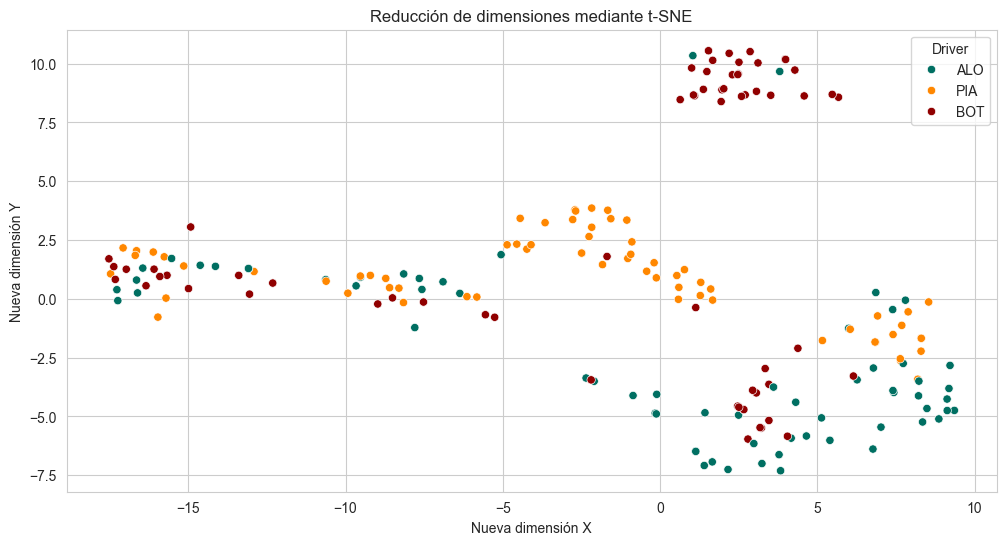

In [221]:
from sklearn.manifold import TSNE # Importar tSNE

tsne = TSNE(n_components=2, random_state=10) # Configuración para reducir a 2 dimensiones y fijar la semilla.
new_2D_data = tsne.fit_transform(data_6D.values) # Transformar nuestros datos a 2 dimensiones


plt.figure(figsize=fig_size); # Tamaño del plot
the_plot = sns.scatterplot(x=new_2D_data[:,0], y=new_2D_data[:,1], hue=filtered_data["Driver"], palette=driver_colors); # Hacer gráfico de dispersión
the_plot.set_xlabel("Nueva dimensión X")
the_plot.set_ylabel("Nueva dimensión Y")
the_plot.set_title("Reducción de dimensiones mediante t-SNE")

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Modifica el gráfico anterior para que se coloree cada punto en función del neumático y no del piloto.
</div>

In [222]:
# Tu código aquí

### **2.2. Visualización dinámica**
En este último apartado haremos uso de la librería Bokeh.

Esta librería genera código html en vez de generar una imágen estática.

In [223]:
from bokeh.plotting import figure, show, ColumnDataSource
from bokeh.io import output_notebook

output_notebook() # Configurar Bokeh

Loading BokehJS ...

In [224]:
# Crear un objeto ColumnDataSource que contenga todos los datos relevantes para el gráfico
source = ColumnDataSource(data=dict(
    x= new_2D_data[:,0],
    y= new_2D_data[:,1],
    driver=filtered_data["Driver"],
    color=filtered_data["Driver"].apply(lambda x: driver_colors[x]),
    lap_time = filtered_data["LapTime"].dt.total_seconds(),
    lap_number = filtered_data["LapNumber"],
    compound = filtered_data["Compound"],
    tire_life = filtered_data["TyreLife"],
    )
)

# Personalizar la información que queremos que se muestre al posar el ratón
TOOLTIPS = """
    <div>
        <div style="padding-right:5px;padding-left:5px">
            <span style="font-size: 20px; color: @color;"><strong>@driver</strong></span>
            <ul style="font-size: 15px; margin-left:-20px; margin-top:0px">
                <li><strong>Lap: </strong>@lap_number</li>
                <li><strong>Tire: </strong>@compound</li>
                <li><strong>Lap Time: </strong>@lap_time</li>
                <li><strong>Tyre life: </strong>@tire_life</li>
            </ul>
        </div>
    </div>
"""

# Hacer el gráfico
p = figure(width=1000, height=600,tooltips=TOOLTIPS)
p.scatter(source = source, x="x", y="y",fill_color="color",line_color=None, size=7)
show(p)

<div class="alert alert-block alert-info">
    <b>Ejercicio:</b> Modifica el gráfico anterior para que se coloree cada punto en función del neumático y no del piloto.
</div>

In [225]:
# Tu código aquí